# Task 5


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from gsvd import gsvd

## 5.1

### Parameters

The propblem dont specify the values for the parameters for part 5.1 so we choose some nice values


In [3]:
n = 100  # number of data points
beta_blur = 10.0  # kernel blurring parameter
delta = 1e-2  # noise level
lam = 1e-1  # regularization parameter

### The true signal

We sample $x(t) = e^t \sin(\pi t)$ at $n$ equidistant points in $[-1, 1]$.


Width of each box: 0.02
Midpoints: [-0.99 -0.97 -0.95 -0.93 -0.91 -0.89 -0.87 -0.85 -0.83 -0.81 -0.79 -0.77
 -0.75 -0.73 -0.71 -0.69 -0.67 -0.65 -0.63 -0.61 -0.59 -0.57 -0.55 -0.53
 -0.51 -0.49 -0.47 -0.45 -0.43 -0.41 -0.39 -0.37 -0.35 -0.33 -0.31 -0.29
 -0.27 -0.25 -0.23 -0.21 -0.19 -0.17 -0.15 -0.13 -0.11 -0.09 -0.07 -0.05
 -0.03 -0.01  0.01  0.03  0.05  0.07  0.09  0.11  0.13  0.15  0.17  0.19
  0.21  0.23  0.25  0.27  0.29  0.31  0.33  0.35  0.37  0.39  0.41  0.43
  0.45  0.47  0.49  0.51  0.53  0.55  0.57  0.59  0.61  0.63  0.65  0.67
  0.69  0.71  0.73  0.75  0.77  0.79  0.81  0.83  0.85  0.87  0.89  0.91
  0.93  0.95  0.97  0.99]


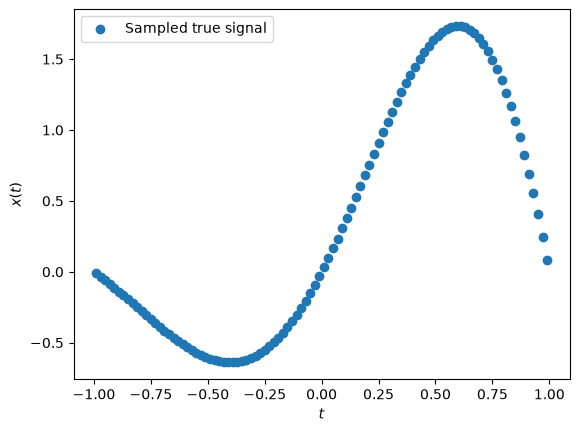

In [24]:
def midpoint_grid(n):
    h = 2 / n  # width
    t = -1 + (np.arange(n) + 0.5) * h  # midpoint of each box
    return h, t


def true_signal(t):
    return np.exp(t) * np.sin(np.pi * t)  # given in the problem statement


h, t = midpoint_grid(n)
x_true_samples = true_signal(t)

print(f"Width of each box: {h}")
print(f"Midpoints: {t}")
plt.scatter(t, x_true_samples, label="Sampled true signal")
plt.xlabel("$t$")
plt.ylabel("$x(t)$")
plt.legend()
plt.show()

### The blur matrix $A$

The blurred signal is
$$b(s) = \int_{-1}^{1} K(s,t)\,x(t)\,dt,$$
where $s, t \in \mathbb{R}^d$ are positions: $t$ is where the signal value comes from and $s$ is where it ends up after blurring. The handout's Gaussian kernel is
$$K(s,t) = c\,\exp\!\big(-(s-t)^T B\,(s-t)\big).$$

**Simplification in 1D.** Our signal lives on a line, so $d = 1$ and the positions $s, t \in [-1, 1]$ are just numbers. The matrix $B$ then becomes a scalar $B = \beta$, so $(s-t)^T B (s-t) = \beta (s-t)^2$ and
$$K(s,t) = c\,e^{-\beta (s-t)^2}.$$
The blur only depends on the distance $s - t$: each point of $x$ is smeared out over its neighbours, and a larger $\beta$ means a narrower blur.

**Box rule.** We split $[-1,1]$ into $n$ boxes of width $h$ with midpoints $t_j$ and approximate the integral at $s = t_i$ by

$$
b(t_i) \approx \sum_{j=1}^{n} h\,K(t_i, t_j)\,x(t_j),
\qquad\text{so}\qquad
A_{ij} = h\,K(t_i, t_j).
$$

We choose $c = \sqrt{\beta/\pi}$ so that $\int K\,dt = 1$; the blur then does not change the size of the signal.


In [26]:
c = np.sqrt(beta_blur / np.pi)
A = h * c * np.exp(-beta_blur * (t[:, None] - t[None, :]) ** 2)

print(f"cond(A) = {np.linalg.cond(A):.1e}")

cond(A) = 1.7e+19


The condition number is enormous, so $A$ is extremely ill-conditioned.


### Blurred, noisy data

We simulate what a instrument would measure: blur the true signal and add noise. Since we chose $x$ ourselves, we know the right answer and can measure how good the reconstruction is.

$$b = A x + e, \qquad e = \delta \cdot \mathcal{N}(0, 1).$$

We fix the random seed so the results are reproducible.


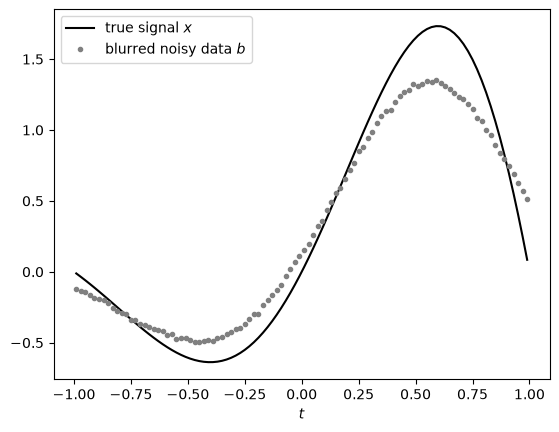

In [31]:
rng = np.random.default_rng(0)  # fixed random seed
b = A @ x_true_samples + delta * rng.standard_normal(n)

plt.plot(t, x_true_samples, "k-", label="true signal $x$")
plt.plot(t, b, ".", color="gray", label="blurred noisy data $b$")
plt.xlabel("$t$")
plt.legend()
plt.show()

To measure quality we use the relative error $\|x - x_{\text{true}}\| / \|x_{\text{true}}\|$.


In [36]:
def rel_err(x):
    return np.linalg.norm(x - x_true_samples) / np.linalg.norm(x_true_samples)


print(f"Relative error of the data b: {rel_err(b):.3f}")

Relative error of the data b: 0.225


### Unregularized solution

We first solve $\min_x \|Ax - b\|_2$ without regularization.
Since $A$ is so ill-conditioned, the noise gets amplified enormously.


Relative error, unregularized: 7.1e+09


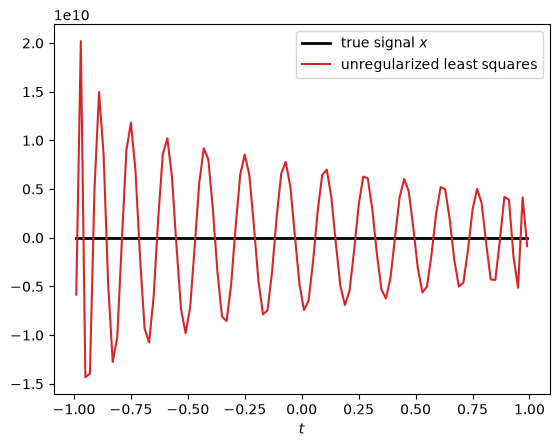

In [38]:
x_ls = np.linalg.lstsq(A, b, rcond=None)[0]

print(f"Relative error, unregularized: {rel_err(x_ls):.1e}")

plt.plot(t, x_true_samples, "k-", lw=2, label="true signal $x$")
plt.plot(t, x_ls, "tab:red", label="unregularized least squares")
plt.xlabel("$t$")
plt.legend()
plt.show()

### Regularized solution with the GSVD

We use $L$ = the first-difference matrix, which penalizes jumps between neighbouring values:

$$L = \begin{bmatrix} 1 & -1 & & \\ & \ddots & \ddots & \\ & & 1 & -1 \end{bmatrix} \in \mathbb{R}^{(n-1)\times n}.$$


In [40]:
L = np.eye(n - 1, n) - np.eye(n - 1, n, k=1)
print(f"L = \n{L}")

L = 
[[ 1. -1.  0. ...  0.  0.  0.]
 [ 0.  1. -1. ...  0.  0.  0.]
 [ 0.  0.  1. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ... -1.  0.  0.]
 [ 0.  0.  0. ...  1. -1.  0.]
 [ 0.  0.  0. ...  0.  1. -1.]]


Compute the GSVD from the given code


In [45]:
U, V, C, S, W, Winv = gsvd(A, L)
U = U[:, :n]
alpha = np.diag(C)
beta = np.append(np.diag(S), 0)

From the report, the solution is $x = W y$ with

$$y_i = \frac{\alpha_i}{\alpha_i^2 + \lambda^2 \beta_i^2}\, u_i^T b.$$


Relative error, regularized: 0.055


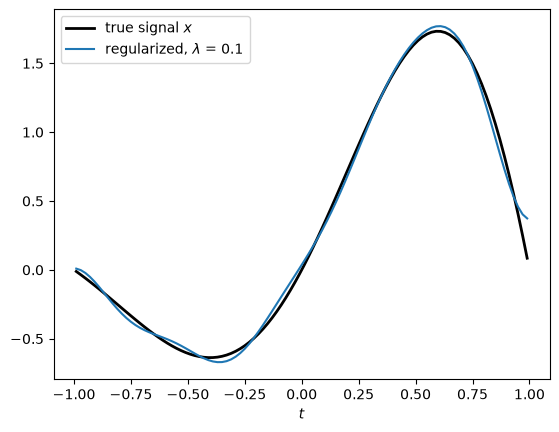

In [47]:
def regularized_solution(b, lam):
    y = alpha / (alpha**2 + lam**2 * beta**2) * (U.T @ b)
    return W @ y


x_reg = regularized_solution(b, lam)

print(f"Relative error, regularized: {rel_err(x_reg):.3f}")

plt.plot(t, x_true_samples, "k-", lw=2, label="true signal $x$")
plt.plot(t, x_reg, "tab:blue", label=f"regularized, $\\lambda$ = {lam:g}")
plt.xlabel("$t$")
plt.legend()
plt.show()

### Comparison

The unregularized solution is many orders of magnitude too large, so it gets its own panel.


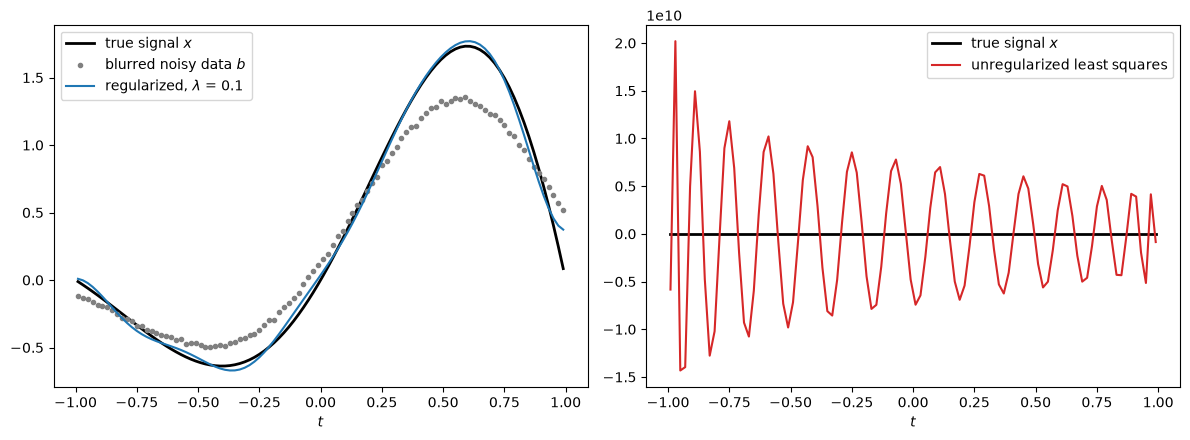

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(t, x_true_samples, "k-", lw=2, label="true signal $x$")
ax1.plot(t, b, ".", color="gray", label="simulated blurred noisy data $b$")
ax1.plot(t, x_reg, "tab:blue", label=f"regularized, $\\lambda$ = {lam:g}")

ax2.plot(t, x_true_samples, "k-", lw=2, label="true signal $x$")
ax2.plot(t, x_ls, "tab:red", label="unregularized least squares")

for ax in (ax1, ax2):
    ax.set_xlabel("$t$")
    ax.legend()

fig.tight_layout()
fig.savefig("assets/task5_1.svg")

## 5.2

### Filter factors

The filter factors are
$$\phi_i(\lambda) = \frac{\gamma_i^2}{\gamma_i^2 + \lambda^2}, \qquad \gamma_i = \frac{\alpha_i}{\beta_i}.$$
We plot them against $\gamma_i$ for a few values of $\lambda$. The dotted lines mark $\gamma_i = \lambda$.


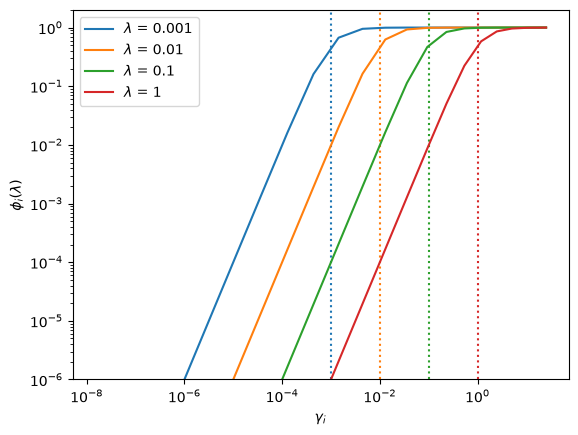

In [64]:
# gamma_i is only defined where beta_i > 0, and needs alpha_i > 0 for a log axis
mask = (alpha > 0) & (beta > 0)
gamma = np.sort(alpha[mask] / beta[mask])

for lam_i in [1e-3, 1e-2, 1e-1, 1]:
    phi = gamma**2 / (gamma**2 + lam_i**2)
    (line,) = plt.loglog(gamma, phi, label=f"$\\lambda$ = {lam_i:g}")
    plt.axvline(lam_i, color=line.get_color(), ls=":")

plt.xlabel("$\\gamma_i$")
plt.ylabel("$\\phi_i(\\lambda)$")
plt.ylim(1e-6, 2)
plt.legend()
plt.savefig("assets/task5_2.svg")
plt.show()

Components with small $\gamma_i$ are the ones where dividing by the small $\alpha_i$ would amplify the noise, so these are exactly the ones that are removed.
Increasing $\lambda$ moves the cut-off $\gamma_i = \lambda$ to the right, so more components are suppressed and the solution becomes smoother.


## 5.3

### Choosing $\lambda$

We solve the problem for many values of $\lambda$ and plot the relative error. Since the GSVD is already computed, each solve is cheap.
The small plots show the solution (colour) and the true signal (black) for a too small, the best and a too large $\lambda$.
Picking the $\lambda$ with the smallest error is only possible here because we know the true signal.


In [ ]:
lams = np.logspace(-4, 2, 100)
errors = [rel_err(regularized_solution(b, lam_i)) for lam_i in lams]

lam_best = lams[np.argmin(errors)]
print(f"Best lambda = {lam_best:.3g}, error = {min(errors):.3f}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(lams, errors, "k-")
ax.set_xlabel("$\\lambda$")
ax.set_ylabel("relative error")
ax.set_ylim(5e-3, 1e2)  # leave room for the small plots

# Three example lambdas, each shown in a small plot:
# (lambda, colour, title, position of the small plot [x, y, width, height] in the big plot)
examples = [
    (lams[0], "tab:red", "under-regularized", [0.06, 0.06, 0.26, 0.28]),
    (lam_best, "tab:green", "best", [0.37, 0.62, 0.26, 0.28]),
    (lams[-1], "tab:purple", "over-regularized", [0.72, 0.06, 0.26, 0.28]),
]
for lam_i, color, title, pos in examples:
    x_i = regularized_solution(b, lam_i)
    ax.plot(lam_i, rel_err(x_i), "o", color=color, ms=8)

    small = ax.inset_axes(pos)
    small.plot(t, x_true_samples, "k-", lw=1)
    small.plot(t, x_i, color=color, lw=1.5)
    small.set_title(f"{title}, $\\lambda$ = {lam_i:.3g}", fontsize=9)
    small.set_xticks([])
    small.set_yticks([])

    # line from the point on the curve to its small plot
    ax.annotate(
        "",
        xy=(lam_i, rel_err(x_i)),
        xytext=(pos[0] + pos[2] / 2, pos[1] + pos[3] / 2),
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="-", color=color, alpha=0.5),
        zorder=0,
    )

fig.savefig("assets/task5_3_error.svg")
plt.show()

- **Too small $\lambda$ (under-regularization):** too little damping, so the noise leaks through and the solution oscillates.
- **Too large $\lambda$ (over-regularization):** too much damping, so the solution becomes too smooth and loses the shape of the signal.

The minimum in between is the best compromise between noise suppression and reconstruction accuracy.


## 5.4

### Different noise levels

We repeat the experiment for three noise levels $\delta$, using the same noise vector scaled to each size. For each $\delta$ we compare the unregularized solution with the regularized one at its best $\lambda$ (found as in 5.3).


In [ ]:
deltas = [1e-3, 1e-2, 1e-1]
noise = np.random.default_rng(0).standard_normal(n)  # same noise shape for every delta

fig, axes = plt.subplots(1, len(deltas), figsize=(15, 4), sharey=True)
print(f"{'delta':>6} | {'error unreg.':>12} | {'best lambda':>11} | {'error reg.':>10}")

for delta_i, ax in zip(deltas, axes):
    b_i = A @ x_true_samples + delta_i * noise

    x_ls_i = np.linalg.lstsq(A, b_i, rcond=None)[0]
    errors_i = [rel_err(regularized_solution(b_i, lam_j)) for lam_j in lams]
    lam_i = lams[np.argmin(errors_i)]
    x_reg_i = regularized_solution(b_i, lam_i)

    print(
        f"{delta_i:>6g} | {rel_err(x_ls_i):>12.1e} | {lam_i:>11.3g} | {rel_err(x_reg_i):>10.3f}"
    )

    ax.plot(t, x_true_samples, "k-", lw=2, label="true signal $x$")
    ax.plot(t, b_i, ".", color="gray", label="data $b$")
    ax.plot(t, x_reg_i, "tab:blue", label=f"regularized, $\\lambda$ = {lam_i:.2g}")
    ax.set_title(f"$\\delta$ = {delta_i:g}")
    ax.set_xlabel("$t$")
    ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig("assets/task5_4.svg")
plt.show()

- **Unregularized:** the error $A^{-1}e$ grows in proportion to the noise, and since $\text{cond}(A) \approx 10^{19}$ the solution is useless already at $\delta = 0.001$.
- **Regularized:** the error grows only slowly, and the best $\lambda$ increases with $\delta$, since more noise means more components must be damped.

So the more noise there is, the more we depend on regularization to keep it from being amplified.


## 5.5

### Automatic choice of $\lambda$: the discrepancy principle

A good solution should fit the data about as well as the noise allows, but not better (then it fits the noise).
The discrepancy principle therefore picks the $\lambda$ where the residual equals the size of the noise:
$$\|A x_\lambda - b\|_2 = \|e\|_2 \approx \delta \sqrt{n}.$$
This only requires the noise level $\delta$, not the true signal.


In [81]:
residuals = np.array(
    [np.linalg.norm(A @ regularized_solution(b, lam_i) - b) for lam_i in lams]
)
lam_dp = lams[np.argmin(np.abs(residuals - delta * np.sqrt(n)))]

print(
    f"Discrepancy principle: lambda = {lam_dp:.3g}, error = {rel_err(regularized_solution(b, lam_dp)):.3f}"
)
print(
    f"Chosen by hand:        lambda = {lam:.3g}, error = {rel_err(regularized_solution(b, lam)):.3f}"
)
print(f"Best (from 5.3):       lambda = {lam_best:.3g}, error = {min(errors):.3f}")

Discrepancy principle: lambda = 0.285, error = 0.084
Chosen by hand:        lambda = 0.1, error = 0.055
Best (from 5.3):       lambda = 0.0933, error = 0.054
